<a href="https://colab.research.google.com/github/GunaSamhith/ML-labActivity/blob/main/8_6_2_SupportVectorMachines.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn import metrics
import seaborn as sns
import matplotlib.pyplot as plt

data = pd.read_csv('/content/spam_email_dataset.csv')

print(data.shape)
data.head()

(400, 3)


,word_frequency,message_length,label
0,10,147,0
1,9,395,0
2,25,423,1
3,6,115,0
4,30,356,1


In [ ]:
data.isnull().sum()

,0
word_frequency,0
message_length,0
label,0


In [ ]:
feature_cols = [
    'word_frequency',
    'message_length'
]

X = data[feature_cols]
y = data['label']

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=5
)

print("Training data:", x_train.shape)
print("Testing data:", x_test.shape)

Training data: (280, 2)
Testing data: (120, 2)


In [ ]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

In [ ]:
model = SVC(
    kernel='rbf',
    random_state=0
)

model.fit(x_train, y_train)

svm_prediction = model.predict(x_test)

print("SVM Prediction:")
print(svm_prediction)

SVM Prediction:
[0 1 0 1 0 0 0 0 0 1 1 0 0 1 1 0 0 0 1 0 0 1 0 0 0 1 1 0 0 0 1 1 0 0 1 0 0
 1 0 1 0 1 0 0 0 1 1 1 0 1 0 1 1 1 0 1 0 1 1 1 0 1 0 1 1 1 1 0 0 0 0 1 0 0
 0 1 1 0 1 1 0 1 0 0 0 0 0 0 1 1 0 1 0 1 0 0 1 1 0 0 1 1 0 0 0 0 0 1 0 0 0
 1 1 0 0 0 1 1 0 0]


In [ ]:
conf_mat = metrics.confusion_matrix(
    y_test,
    svm_prediction
)

print("SVM [kernel - rbf]")
print("Confusion Matrix:\n", conf_mat)

accuracy_score = metrics.accuracy_score(
    y_test,
    svm_prediction
)

print("Accuracy Score:", accuracy_score)

print(
    "Accuracy in Percentage:",
    int(accuracy_score * 100),
    "%"
)

print("\nClassification Report:")
print(
    metrics.classification_report(
        y_test,
        svm_prediction
    )
)

SVM [kernel - rbf]
Confusion Matrix:
 [[55  2]
 [14 49]]
Accuracy Score: 0.8666666666666667
Accuracy in Percentage: 86 %

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.96      0.87        57
           1       0.96      0.78      0.86        63

    accuracy                           0.87       120
   macro avg       0.88      0.87      0.87       120
weighted avg       0.88      0.87      0.87       120



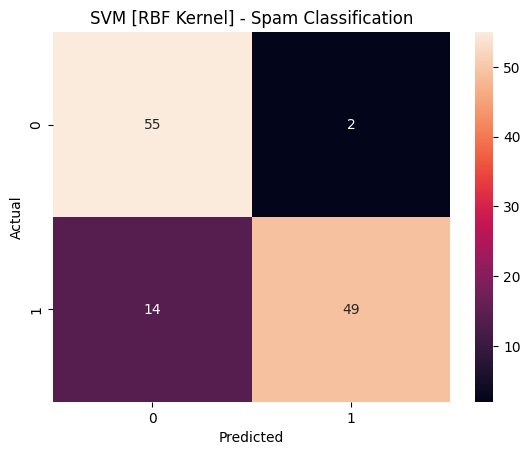

In [ ]:
conf_mat = pd.crosstab(
    y_test,
    svm_prediction,
    rownames=['Actual'],
    colnames=['Predicted']
)

sns.heatmap(
    conf_mat,
    annot=True,
    fmt='d'
)

plt.title('SVM [RBF Kernel] - Spam Classification')
plt.show()

In [ ]:
# Test a new email

new_email = pd.DataFrame({
    'word_frequency': [25],
    'message_length': [350]
})

new_email_scaled = sc.transform(new_email)

prediction = model.predict(new_email_scaled)

if prediction[0] == 1:
    print("Prediction: SPAM")
else:
    print("Prediction: NOT SPAM")

Prediction: SPAM


In [ ]:
linear_model = SVC(
    kernel='linear',
    random_state=0
)

linear_model.fit(x_train, y_train)

linear_prediction = linear_model.predict(x_test)

linear_accuracy = metrics.accuracy_score(
    y_test,
    linear_prediction
)

rbf_accuracy = metrics.accuracy_score(
    y_test,
    svm_prediction
)

print("Linear SVM Accuracy:",
      int(linear_accuracy * 100), "%")

print("RBF SVM Accuracy:",
      int(rbf_accuracy * 100), "%")

Linear SVM Accuracy: 86 %
RBF SVM Accuracy: 86 %
